Import Plugin

In [ ]:
import string
import pandas as pd
import matplotlib.pyplot as plt
from nltk import sent_tokenize
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

In [ ]:
paragraph_danantara = """Jakarta: Badan Pengelola Investasi Daya Anagata Nusantara (BPI Danantara) siap mengawal realisasi investasi yang telah disepakati dengan Qatar. Kesepakatan antara Indonesia dan Qatar merupakan buah dari kunjungan resmi Presiden Prabowo Subianto ke Doha.

Pemerintah Republik Indonesia dan Pemerintah Qatar menggelar diskusi untuk menyepakati kemitraan strategis (co-partnership) dalam pengelolaan dana investasi untuk Indonesia yang akan berfokus di berbagai sektor pembangunan.

Salah satu hasil utama dari kunjungan tersebut adalah untuk membentuk dana investasi bersama senilai USD4 miliar. Dana ini akan difokuskan pada pengembangan berbagai sektor di antaranya termasuk tapi tidak terbatas pada hilirisasi industri, energi terbarukan, dan fasilitas kesehatan di Indonesia.

"Kami menyambut baik kepercayaan yang diberikan oleh Pemerintah Qatar melalui pembentukan dana bersama ini," kata CEO Danantara Indonesia Rosan Perkasa Roeslani dalam keterangan tertulis, Selasa, 15 April 2025.

Presiden Prabowo menyampaikan masing-masing negara akan berkontribusi sebesar USD2 miliar dalam dana tersebut. Dana itu akan dikelola oleh BPI Danantara bersama dengan Qatar Investment Authority (QIA) dalam co-partnership. Buka peluang investasi sektor strategis
Dana tersebut akan difokuskan pada peluang investasi di berbagai sektor strategis, antara lain hilirisasi, kesehatan, energi terbarukan, teknologi, serta sektor-sektor lain yang dipandang relevan oleh pengelola dana.

"Danantara Indonesia siap menjalankan mandat tersebut dengan menerapkan tata kelola investasi yang prudent, transparan, dan berorientasi pada hasil. Fokus kami adalah memastikan bahwa setiap proyek yang didanai memberikan dampak strategis dan berkelanjutan bagi perekonomian nasional," ujar Rosan.

Lebih lanjut, Rosan menegaskan, kolaborasi ini menjadi bukti kepercayaan dunia internasional terhadap kapasitas kelembagaan Indonesia dalam mengelola investasi berskala besar.

"Kemitraan ini merupakan langkah konkret dalam membangun kepercayaan dengan mitra global strategis seperti Qatar. Ini menunjukkan bahwa Indonesia tidak hanya menjadi tujuan investasi, tetapi juga memiliki kapasitas kelembagaan yang mumpuni untuk mengelola nvestasi secara profesional dan akuntabel," ungkapnya.

Inisiatif co-partnership dan perluasan kerja sama strategis ini diharapkan tidak hanya memperkuat hubungan diplomatik kedua negara, tetapi juga memberikan kontribusi nyata terhadap percepatan pembangunan ekonomi dan peningkatan kesejahteraan masyarakat Indonesia. Jangan lupa ikuti update berita lainnya dan follow  akun
Google News Metrotvnews.com dan Channel WhatsApp Metro TV

(Eko Nordiansyah)"""

Preview Teks Berita Danantara

In [ ]:
print(paragraph_danantara)

Jakarta: Badan Pengelola Investasi Daya Anagata Nusantara (BPI Danantara) siap mengawal realisasi investasi yang telah disepakati dengan Qatar. Kesepakatan antara Indonesia dan Qatar merupakan buah dari kunjungan resmi Presiden Prabowo Subianto ke Doha.

Pemerintah Republik Indonesia dan Pemerintah Qatar menggelar diskusi untuk menyepakati kemitraan strategis (co-partnership) dalam pengelolaan dana investasi untuk Indonesia yang akan berfokus di berbagai sektor pembangunan.

Salah satu hasil utama dari kunjungan tersebut adalah untuk membentuk dana investasi bersama senilai USD4 miliar. Dana ini akan difokuskan pada pengembangan berbagai sektor di antaranya termasuk tapi tidak terbatas pada hilirisasi industri, energi terbarukan, dan fasilitas kesehatan di Indonesia.

"Kami menyambut baik kepercayaan yang diberikan oleh Pemerintah Qatar melalui pembentukan dana bersama ini," kata CEO Danantara Indonesia Rosan Perkasa Roeslani dalam keterangan tertulis, Selasa, 15 April 2025.

Presiden 

Data Clean

In [ ]:
sentences_dirty = sent_tokenize(paragraph_danantara)
sentences = []
translator = str.maketrans('', '', string.punctuation)
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

for i in range(len(sentences_dirty)):
    current_sentence = sentences_dirty[i]

    #lower
    current_sentence = current_sentence.lower()

    #remove punctuations
    current_sentence = current_sentence.replace('\n\n', ' ').translate(translator)

    #remove stopwords
    current_sentence = stopword_remover.remove(current_sentence)

    sentences.append(current_sentence)

print(sentences)

['jakarta badan pengelola investasi daya anagata nusantara bpi danantara siap mengawal realisasi investasi telah disepakati qatar', 'kesepakatan indonesia qatar merupakan buah kunjungan resmi presiden prabowo subianto doha', 'pemerintah republik indonesia pemerintah qatar menggelar diskusi menyepakati kemitraan strategis copartnership pengelolaan dana investasi indonesia akan berfokus berbagai sektor pembangunan', 'salah satu hasil utama kunjungan tersebut untuk membentuk dana investasi bersama senilai usd4 miliar', 'dana akan difokuskan pengembangan berbagai sektor antaranya termasuk tidak terbatas hilirisasi industri energi terbarukan fasilitas kesehatan indonesia', 'menyambut baik kepercayaan diberikan pemerintah qatar melalui pembentukan dana bersama kata ceo danantara indonesia rosan perkasa roeslani keterangan tertulis selasa 15 april 2025', 'presiden prabowo menyampaikan masingmasing negara berkontribusi sebesar usd2 miliar dana tersebut', 'dana akan dikelola bpi danantara bersa

TF-IDF

In [4]:
vectorizer = TfidfVectorizer()
features = vectorizer.fit_transform(sentences)

print(features.shape)

words = vectorizer.get_feature_names_out()
tfidf_df = pd.DataFrame(features.toarray(), columns=words)
tfidf_df

(16, 179)


,15,2025,adalah,akan,akun,akuntabel,anagata,antaranya,april,authority,...,tv,ujar,ungkapnya,untuk,update,usd2,usd4,utama,whatsapp,yang
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.273324,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.198104,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.301403,0.000000,0.0000,0.301403,0.301403,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.214506,0.000000,0.000000,0.000000,0.27527,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000
5,0.229257,0.229257,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.229257,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000
6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.3362,0.000000,0.000000,0.000000,0.000000
7,0.000000,0.000000,0.000000,0.279830,0.000000,0.000000,0.000000,0.00000,0.000000,0.359098,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000
8,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.207281
9,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000


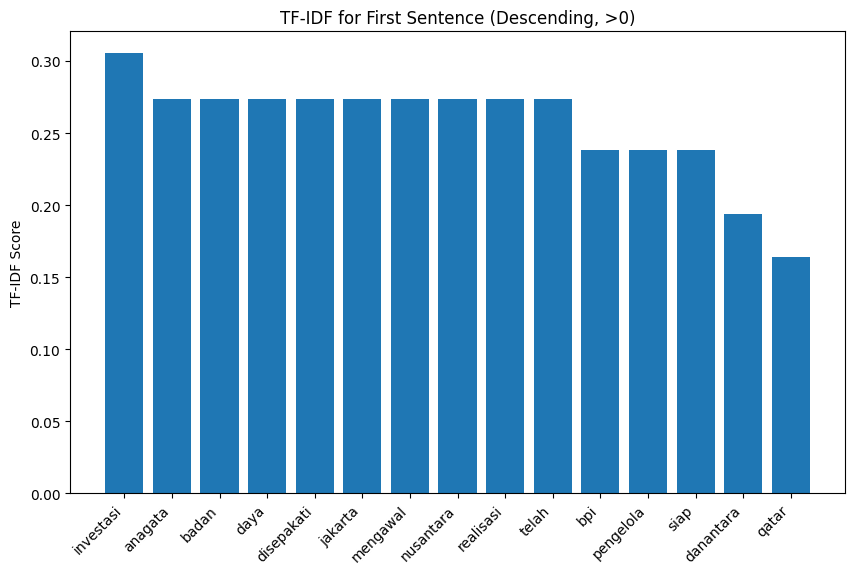

In [5]:
first_sentence_tfidf = tfidf_df.iloc[0]

first_sentence_tfidf = first_sentence_tfidf[first_sentence_tfidf > 0].sort_values(ascending=False)

# plot
plt.figure(figsize=(10, 6))
plt.bar(first_sentence_tfidf.index, first_sentence_tfidf.values)
plt.xticks(rotation=45, ha='right')
plt.ylabel("TF-IDF Score")
plt.title("TF-IDF for First Sentence (Descending, >0)")
plt.show()

TF-IDF untuk kata "Investasi"

In [7]:
investasi_column = tfidf_df["investasi"]

print(f"TF-IDF of 'investasi'\n")
for i, value in enumerate(investasi_column):
    print(f"Sentence {i + 1}: {value}")

TF-IDF of 'investasi'

Sentence 1: 0.3053107330181949
Sentence 2: 0.0
Sentence 3: 0.14198616546063283
Sentence 4: 0.16833780474072477
Sentence 5: 0.0
Sentence 6: 0.0
Sentence 7: 0.0
Sentence 8: 0.0
Sentence 9: 0.2315391748093927
Sentence 10: 0.1676131892656669
Sentence 11: 0.0
Sentence 12: 0.15017541365623904
Sentence 13: 0.0
Sentence 14: 0.15411228716163702
Sentence 15: 0.0
Sentence 16: 0.0


Text Summarization

In [12]:
averages = []

for index, data in tfidf_df.iterrows():
    row_average = 0
    # get average of tf-idf for all words that appear in the sentence
    if (data != 0).sum() > 0:
        row_average = data.sum() / (data != 0).sum()

        averages.append(row_average)

overall_average = 0
if (len(averages) > 0):
    overall_average = sum(averages) / len(averages)

print(f"Minimum value: {overall_average}")
for i in range(0, len(averages)):
    print(f"Sentence {i + 1} value: {averages[i]}")

final_result = ""
final_result_neat = ""

sentences_in_summary = []
for i in range(len(averages)):
    if (averages[i] > overall_average):
        final_result +=  " " + sentences_dirty[i]
        final_result_neat += " " + sentences_dirty[i] + "\n"
        sentences_in_summary.append(i)

print("\nSentences in summary:")
print(sentences_in_summary)

Minimum value: 0.25416878181864444
Sentence 1 value: 0.2558109212942385
Sentence 2 value: 0.2966266898604991
Sentence 3 value: 0.22612595197681737
Sentence 4 value: 0.2630192233394888
Sentence 5 value: 0.23918790505775156
Sentence 6 value: 0.20530860122998593
Sentence 7 value: 0.29800188451372117
Sentence 8 value: 0.2963011214975356
Sentence 9 value: 0.21562986551413443
Sentence 10 value: 0.26232762998468595
Sentence 11 value: 0.265659398669428
Sentence 12 value: 0.23917253560377968
Sentence 13 value: 0.3119420235346888
Sentence 14 value: 0.24669685182028062
Sentence 15 value: 0.20235428016494209
Sentence 16 value: 0.24253562503633302

Sentences in summary:
[0, 1, 3, 6, 7, 9, 10, 12]


In [ ]:
print("Word counts:")
print(f"Original text: {len(paragraph_danantara)}")
print(f"Summary: {len(final_result)}")

print("\nFinal summary:")
print(final_result)

Word counts:
Original text: 2657
Summary: 1003

Final summary:
 Jakarta: Badan Pengelola Investasi Daya Anagata Nusantara (BPI Danantara) siap mengawal realisasi investasi yang telah disepakati dengan Qatar. Kesepakatan antara Indonesia dan Qatar merupakan buah dari kunjungan resmi Presiden Prabowo Subianto ke Doha. Salah satu hasil utama dari kunjungan tersebut adalah untuk membentuk dana investasi bersama senilai USD4 miliar. Presiden Prabowo menyampaikan masing-masing negara akan berkontribusi sebesar USD2 miliar dalam dana tersebut. Dana itu akan dikelola oleh BPI Danantara bersama dengan Qatar Investment Authority (QIA) dalam co-partnership. "Danantara Indonesia siap menjalankan mandat tersebut dengan menerapkan tata kelola investasi yang prudent, transparan, dan berorientasi pada hasil. Fokus kami adalah memastikan bahwa setiap proyek yang didanai memberikan dampak strategis dan berkelanjutan bagi perekonomian nasional," ujar Rosan. "Kemitraan ini merupakan langkah konkret dalam 